# Filter Operators

In [1]:
import cv_depot.api as cvd

In [59]:
src = '/home/ubuntu/images/misc/p-ring_s-rndr001_d-demo_v001_f0300.exr'
image = cvd.Image.read(src)[:, :, 'rgb']

<font size=4 color="#EBB483"><br>**canny_edges** detects solid edges in an image.

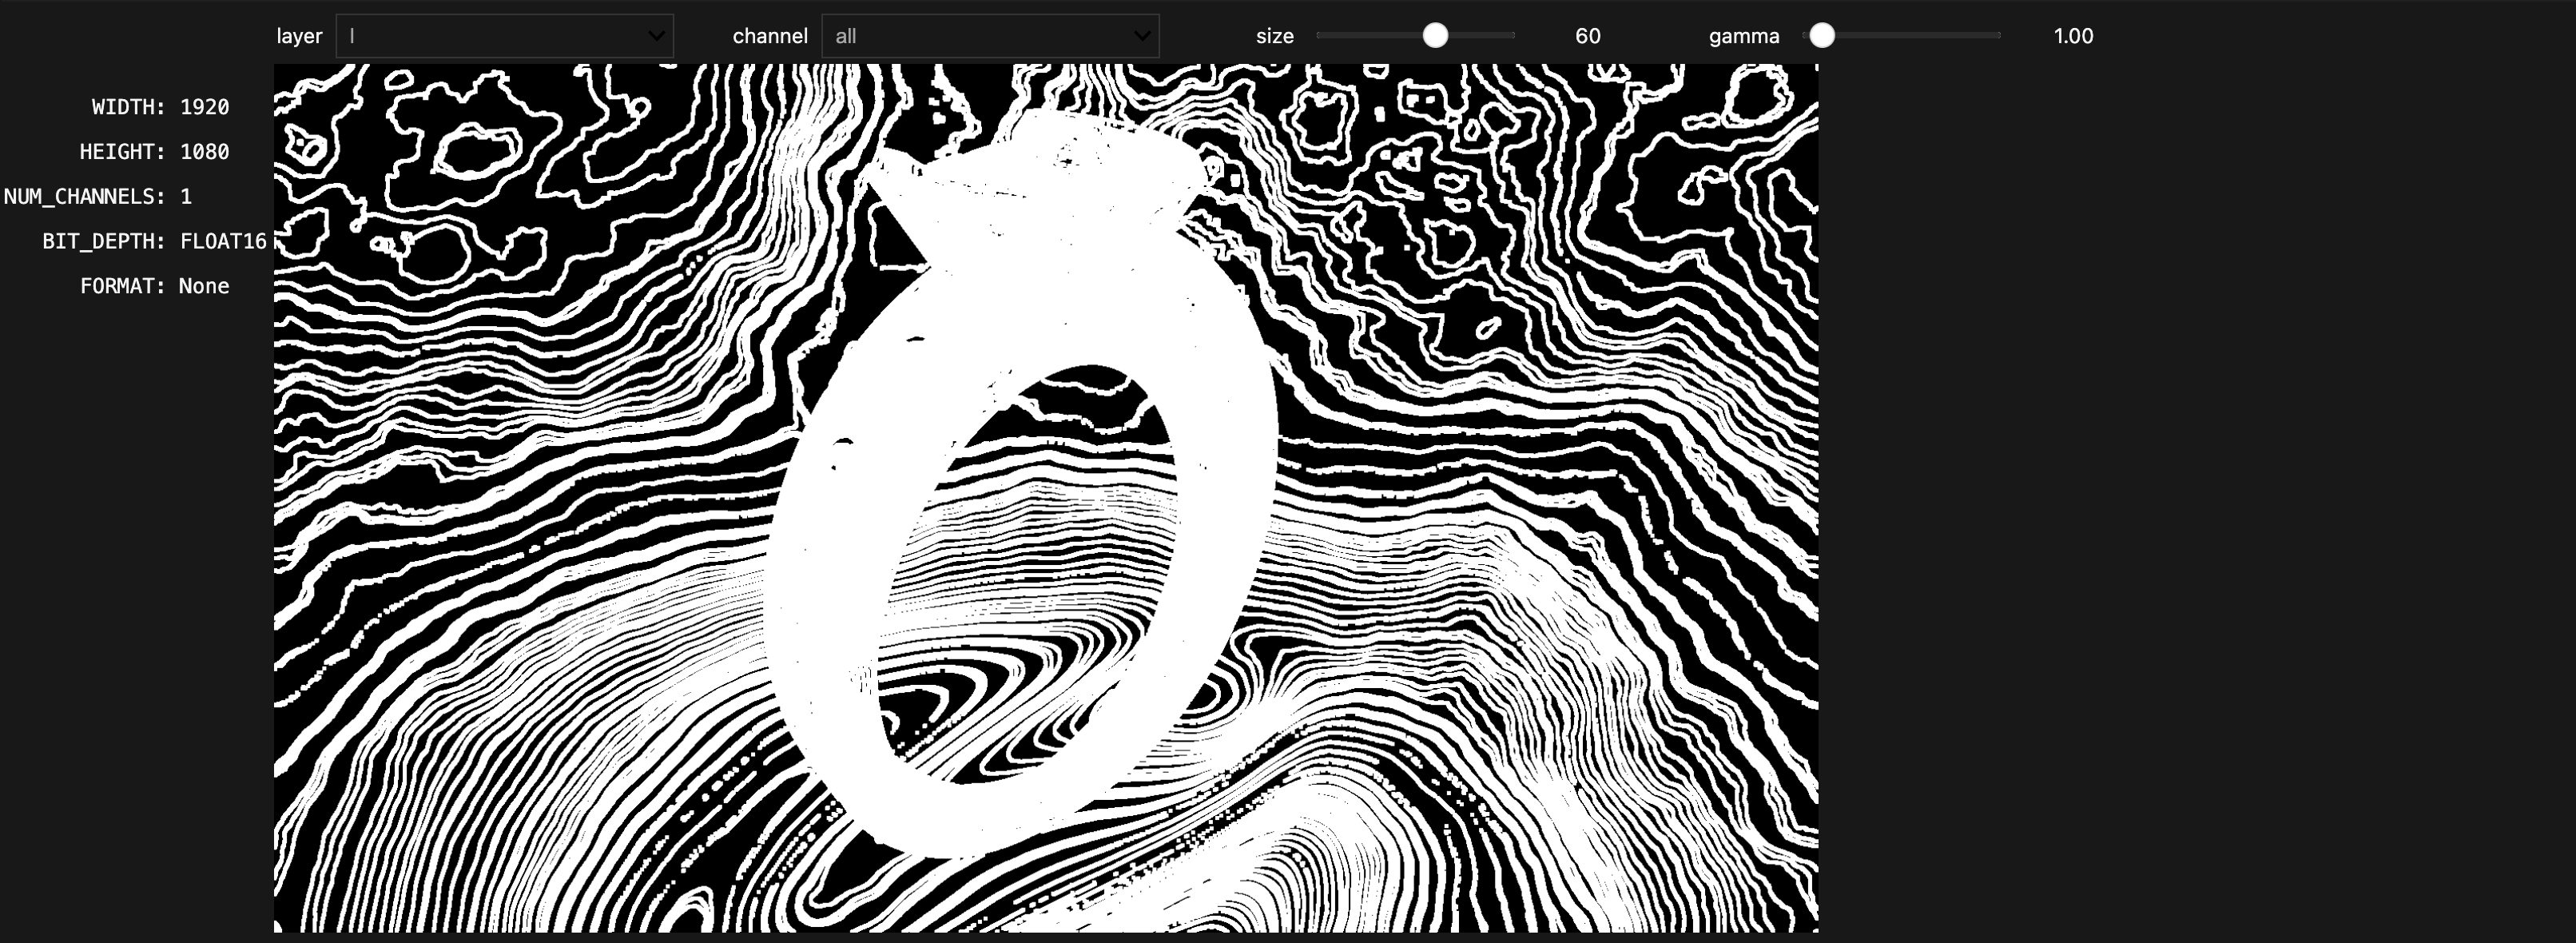

In [133]:
cvd.ops.filter.canny_edges(image, size=2)

<font size=4 color="#EBB483"><br>**gamma** adjusts the midpoint values of an image.

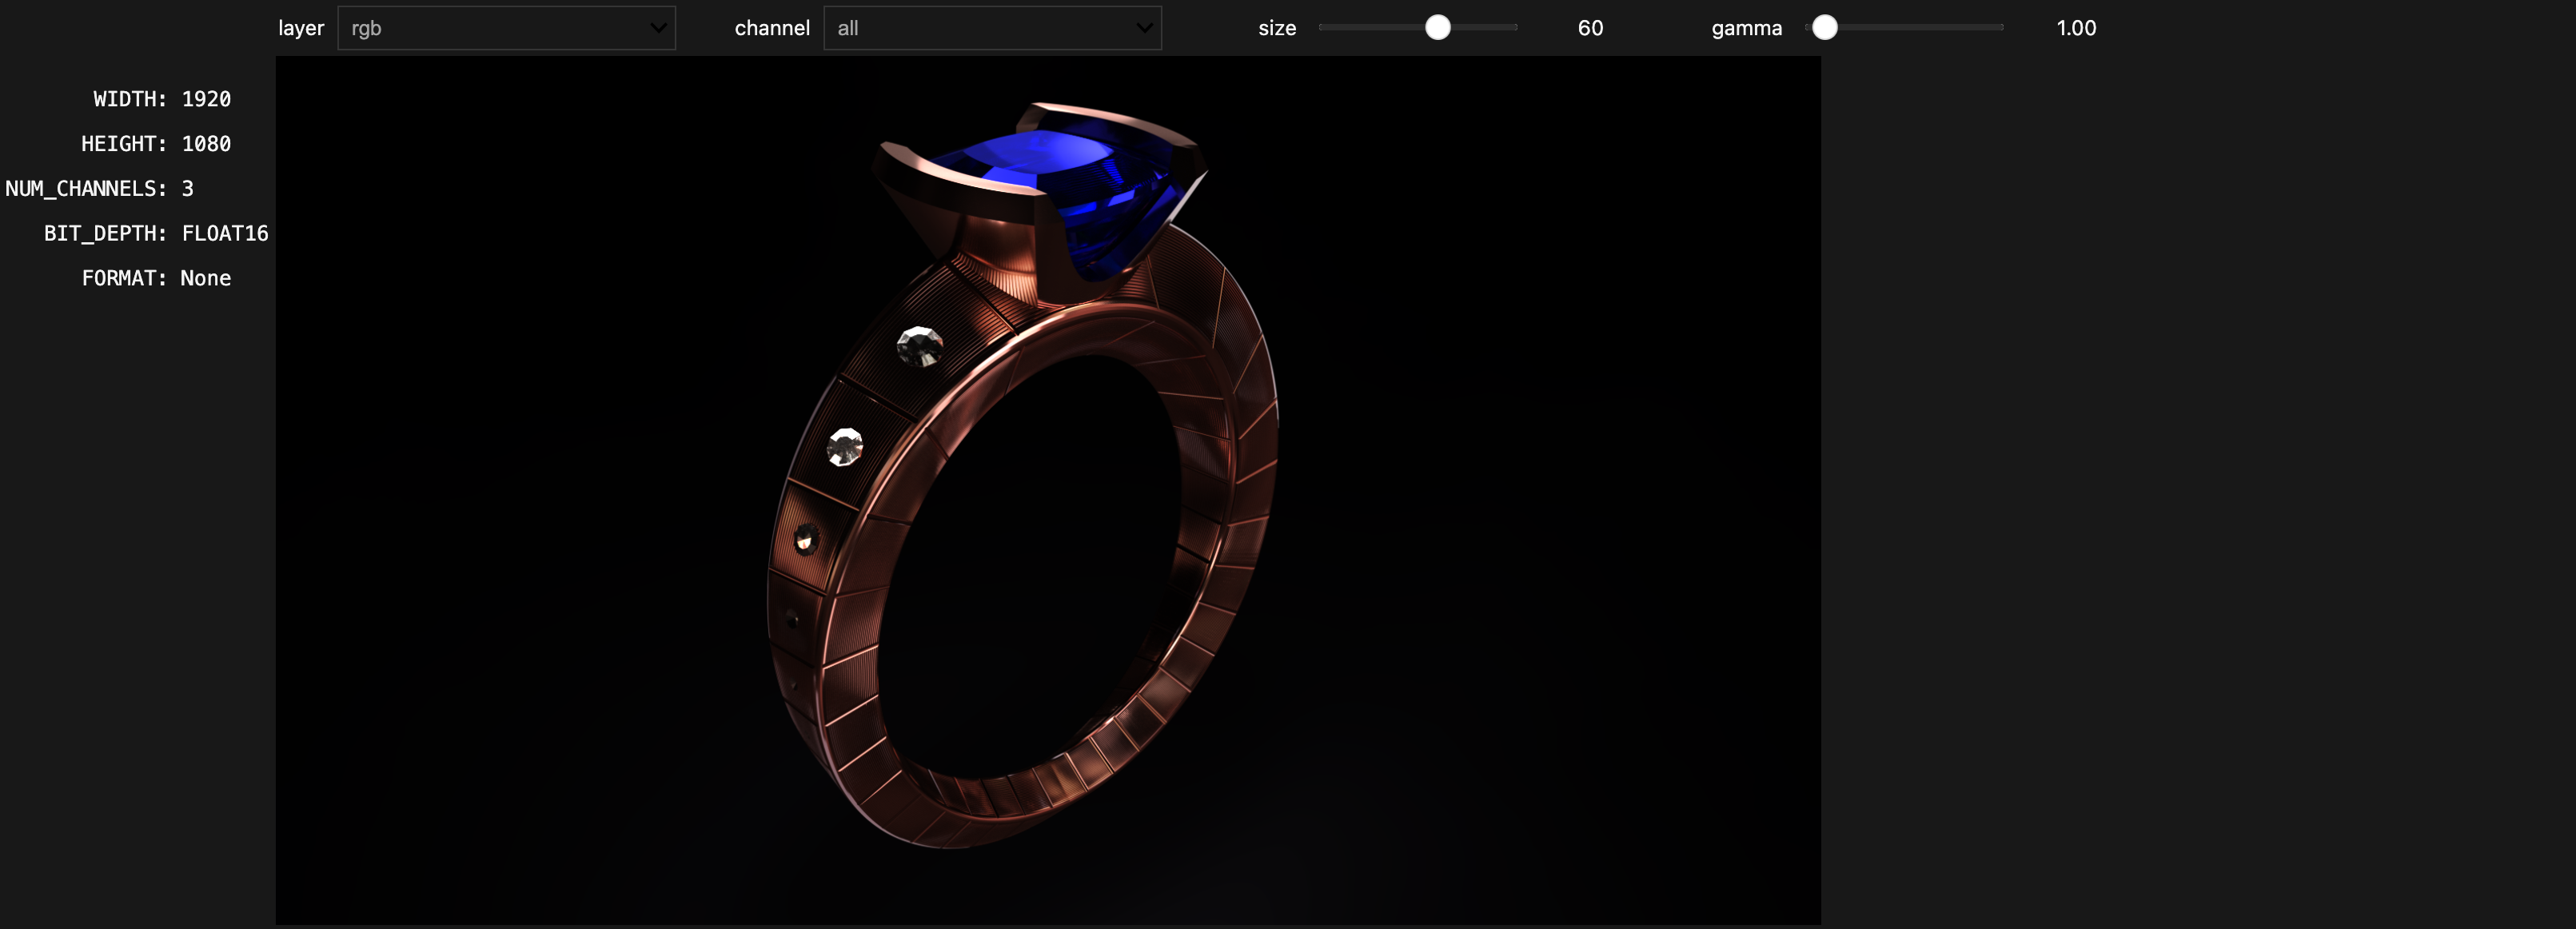

In [134]:
cvd.ops.filter.gamma(image, 0.5)

<font size=4 color="#EBB483"><br>**kmeans** performs a kmeans operation on the image according to the given centroids.

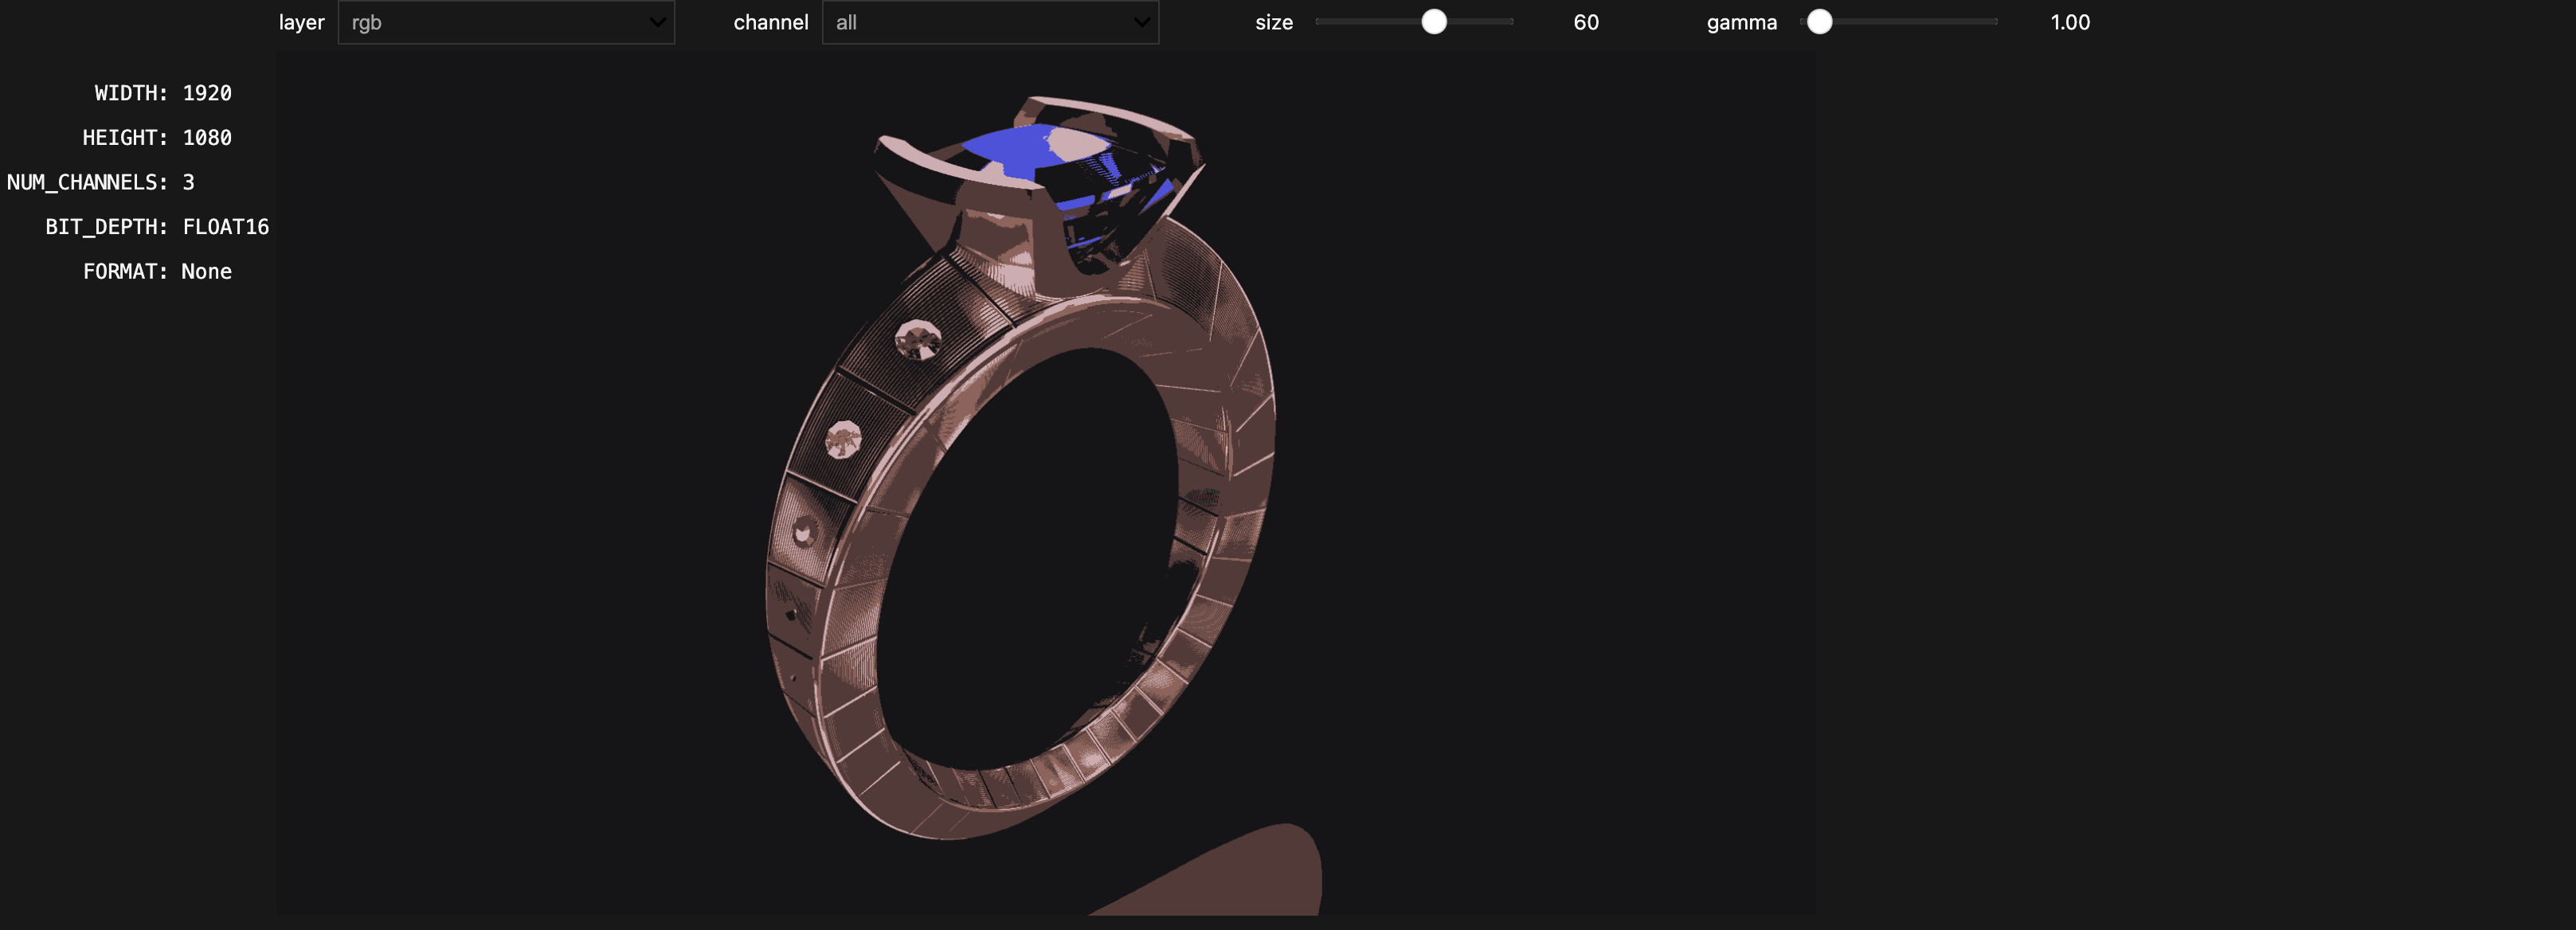

In [135]:
cvd.ops.filter.kmeans(image, num_centroids=5)

<font size=4 color="#EBB483"><br>**generate_report=True** will return a kmeans image and a kmeans report.

In [74]:
kmeans, report = cvd.ops.filter.kmeans(image, num_centroids=5, generate_report=True)
report

{'compactness': 12569.278241442044,
 'labels': array([[4],
        [4],
        [4],
        ...,
        [4],
        [4],
        [4]], shape=(2073600, 1), dtype=int32),
 'centroids': array([[0.68535835, 0.50402266, 0.45815682],
        [0.9150719 , 0.8085163 , 0.7850709 ],
        [0.3748067 , 0.2621596 , 0.24497575],
        [0.37509632, 0.3891192 , 0.9051946 ],
        [0.08828657, 0.08258259, 0.09307582]], dtype=float32)}

<font size=4 color="#EBB483"><br>**key_exact_color** is used to produce a mask of an exact color in an image.

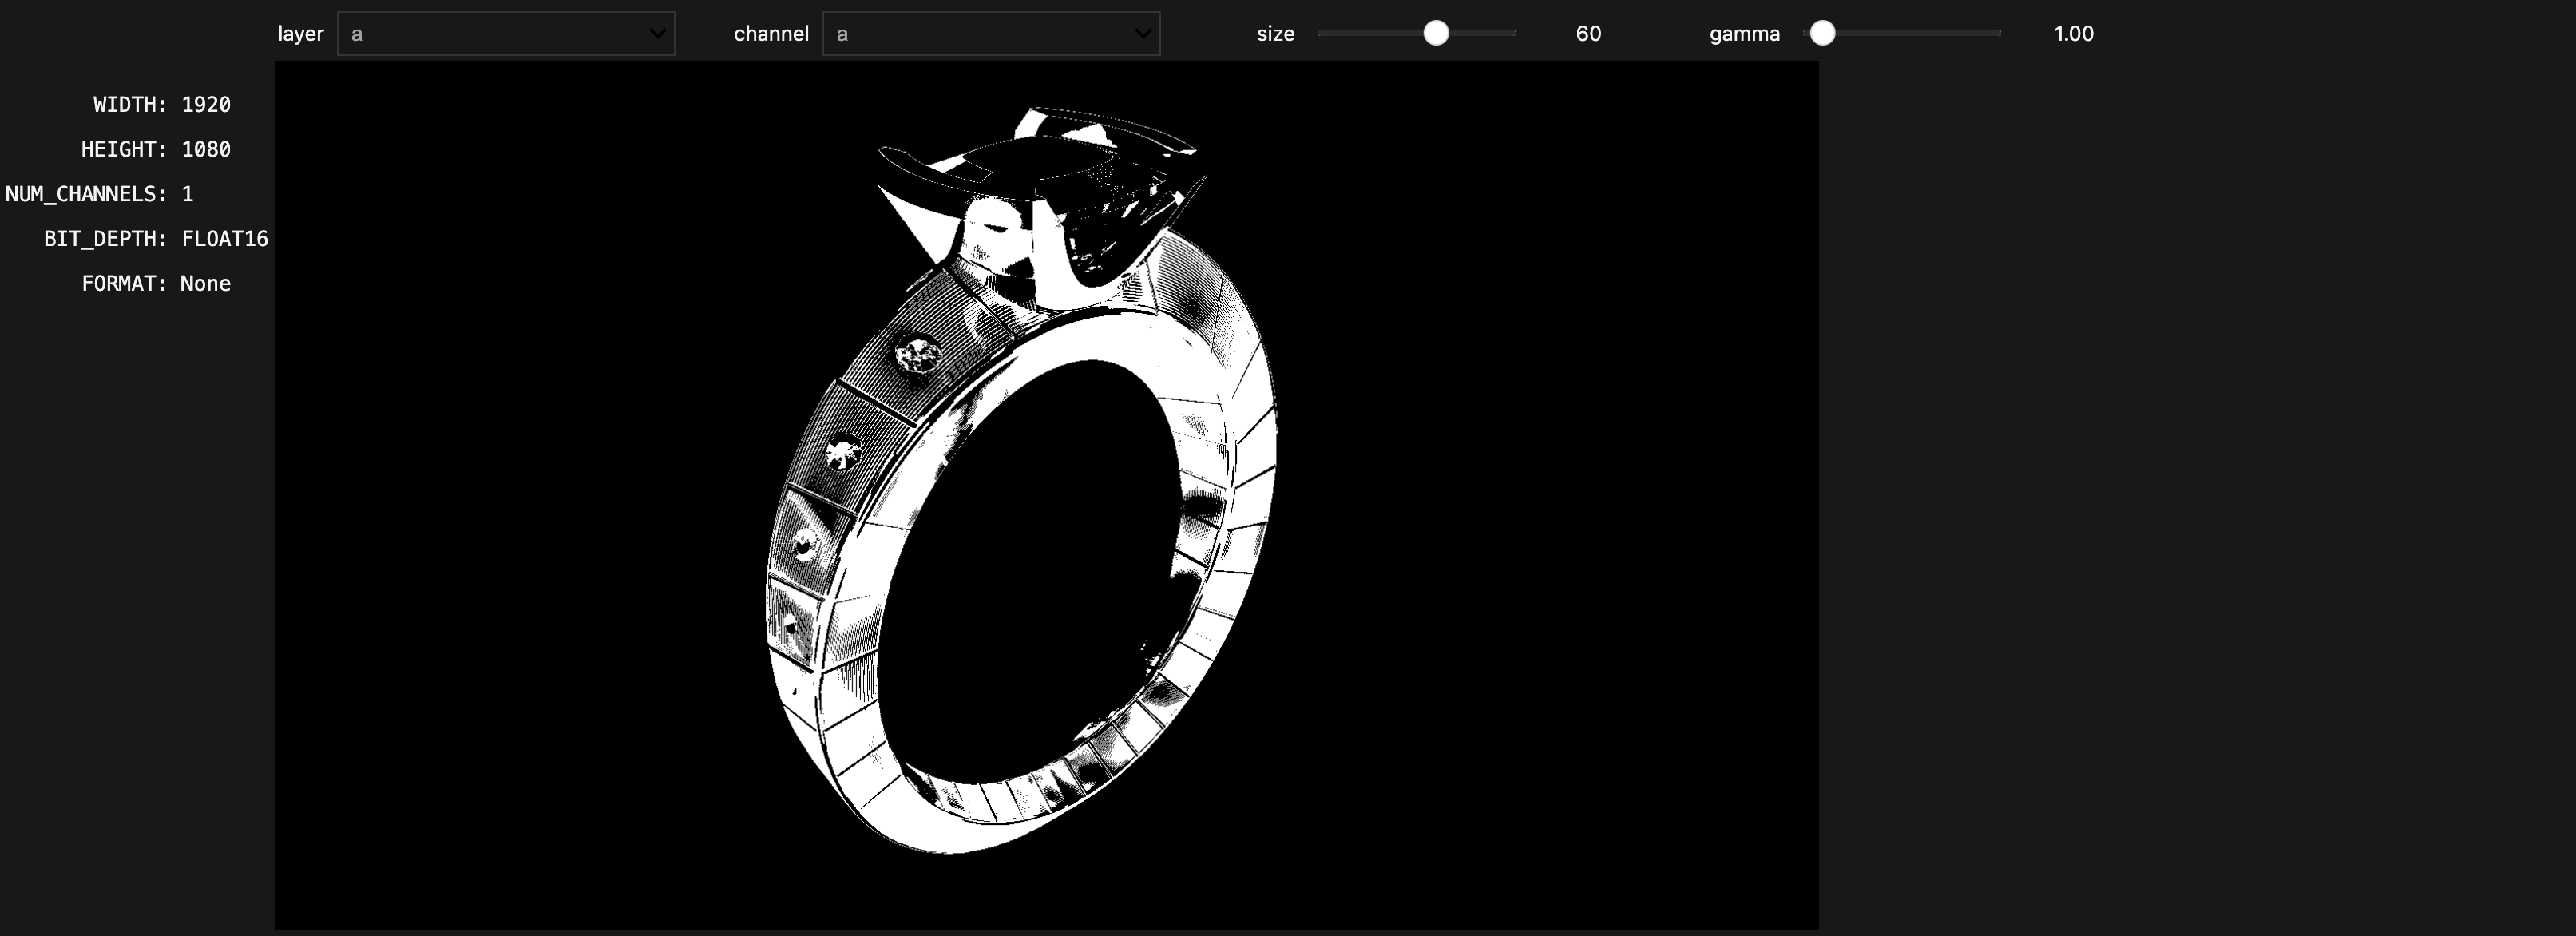

In [136]:
color = report['centroids'][2].astype('float16')
color = cvd.Color.from_array(color)
key = cvd.ops.filter.key_exact_color(kmeans, color)[:, :, 'a']
key

<font size=4 color="#EBB483"><br>**linear_smooth** blurs an image and then thresholds it. It helps to fill holes and round out masks countours.

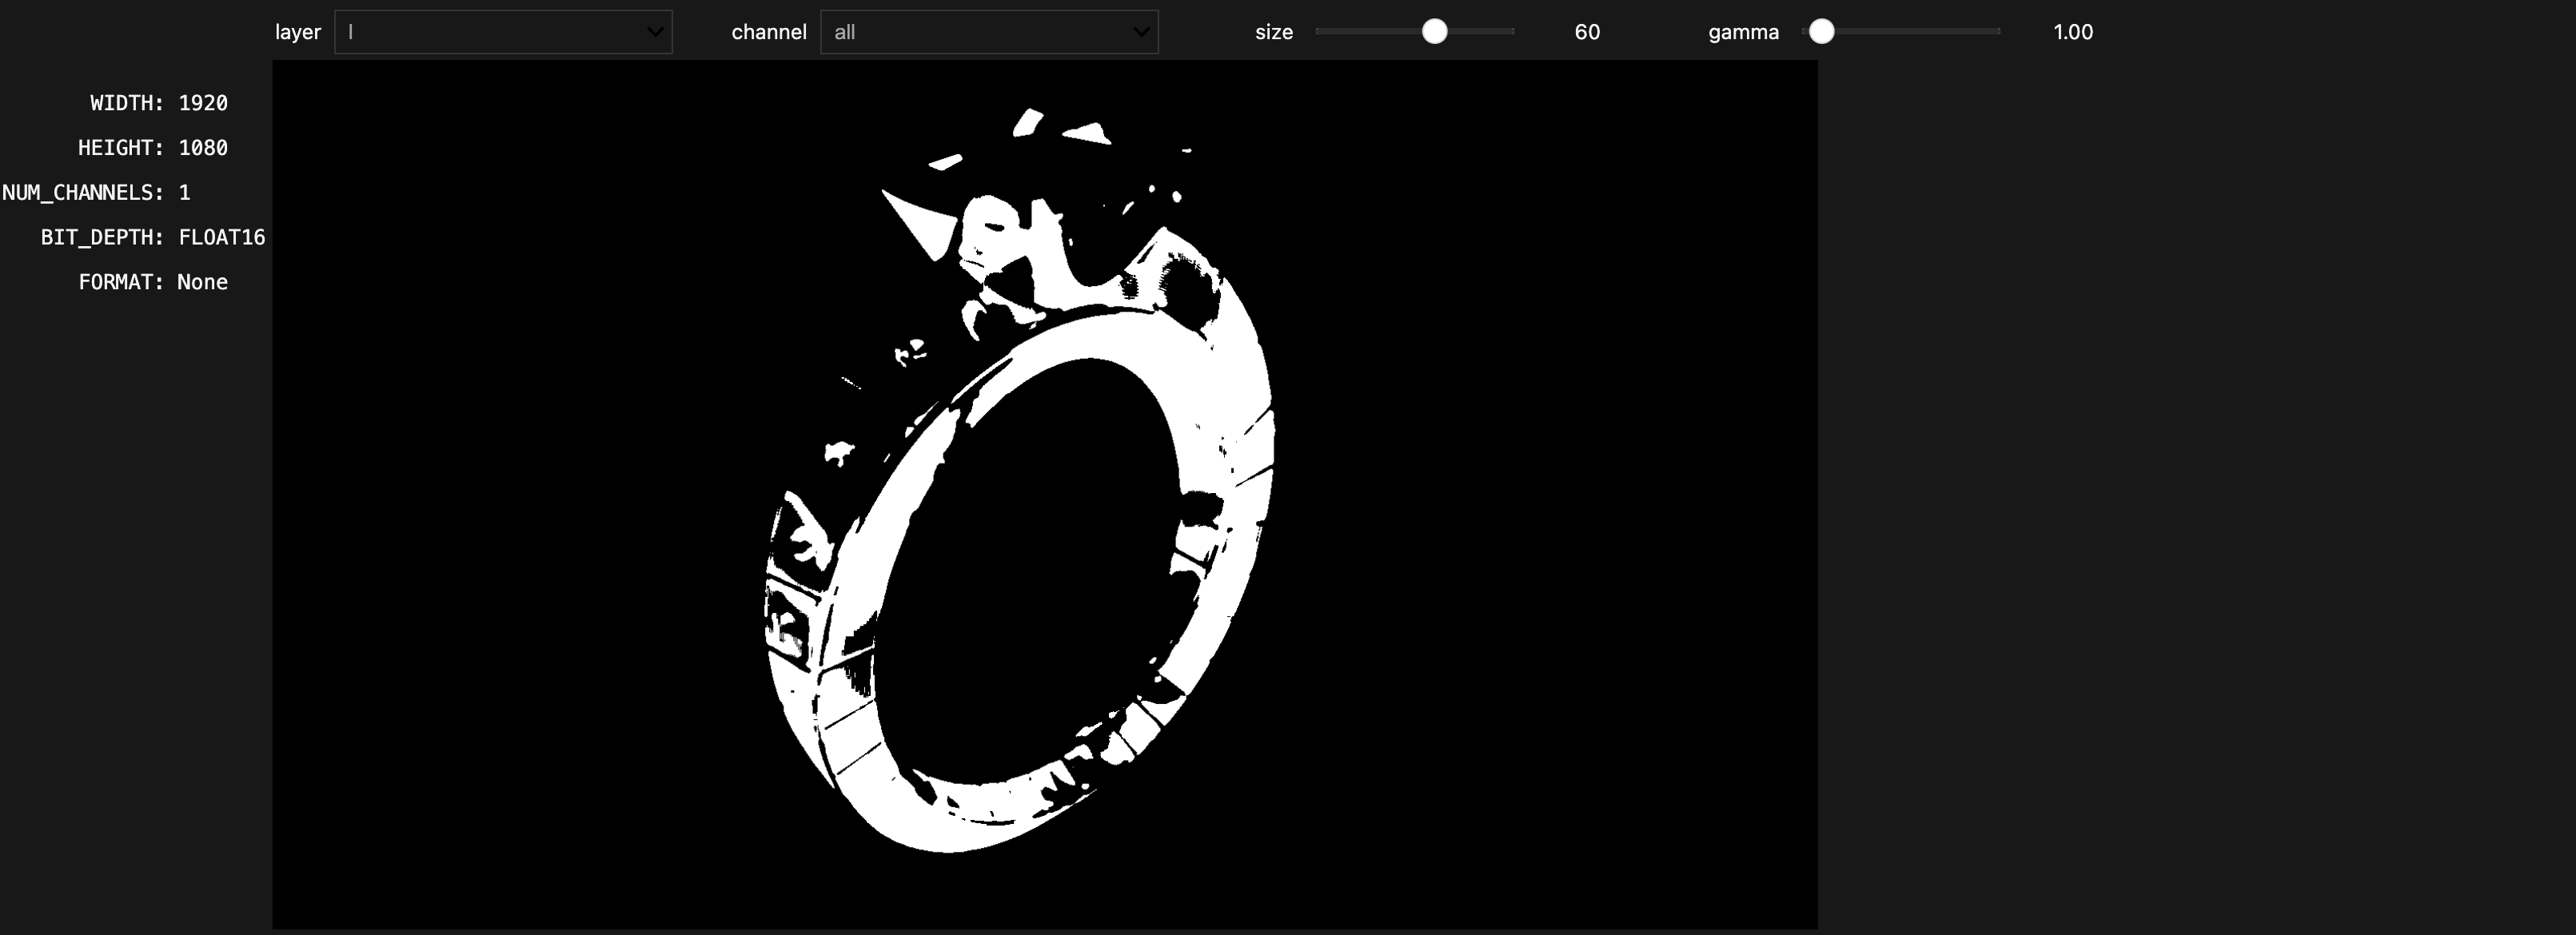

In [137]:
cvd.ops.filter.linear_smooth(key, blur=7, lower=0.58, upper=0.59)

<font size=4 color="#EBB483"><br>**tophat** performs tophat morphological operation on a given mask.

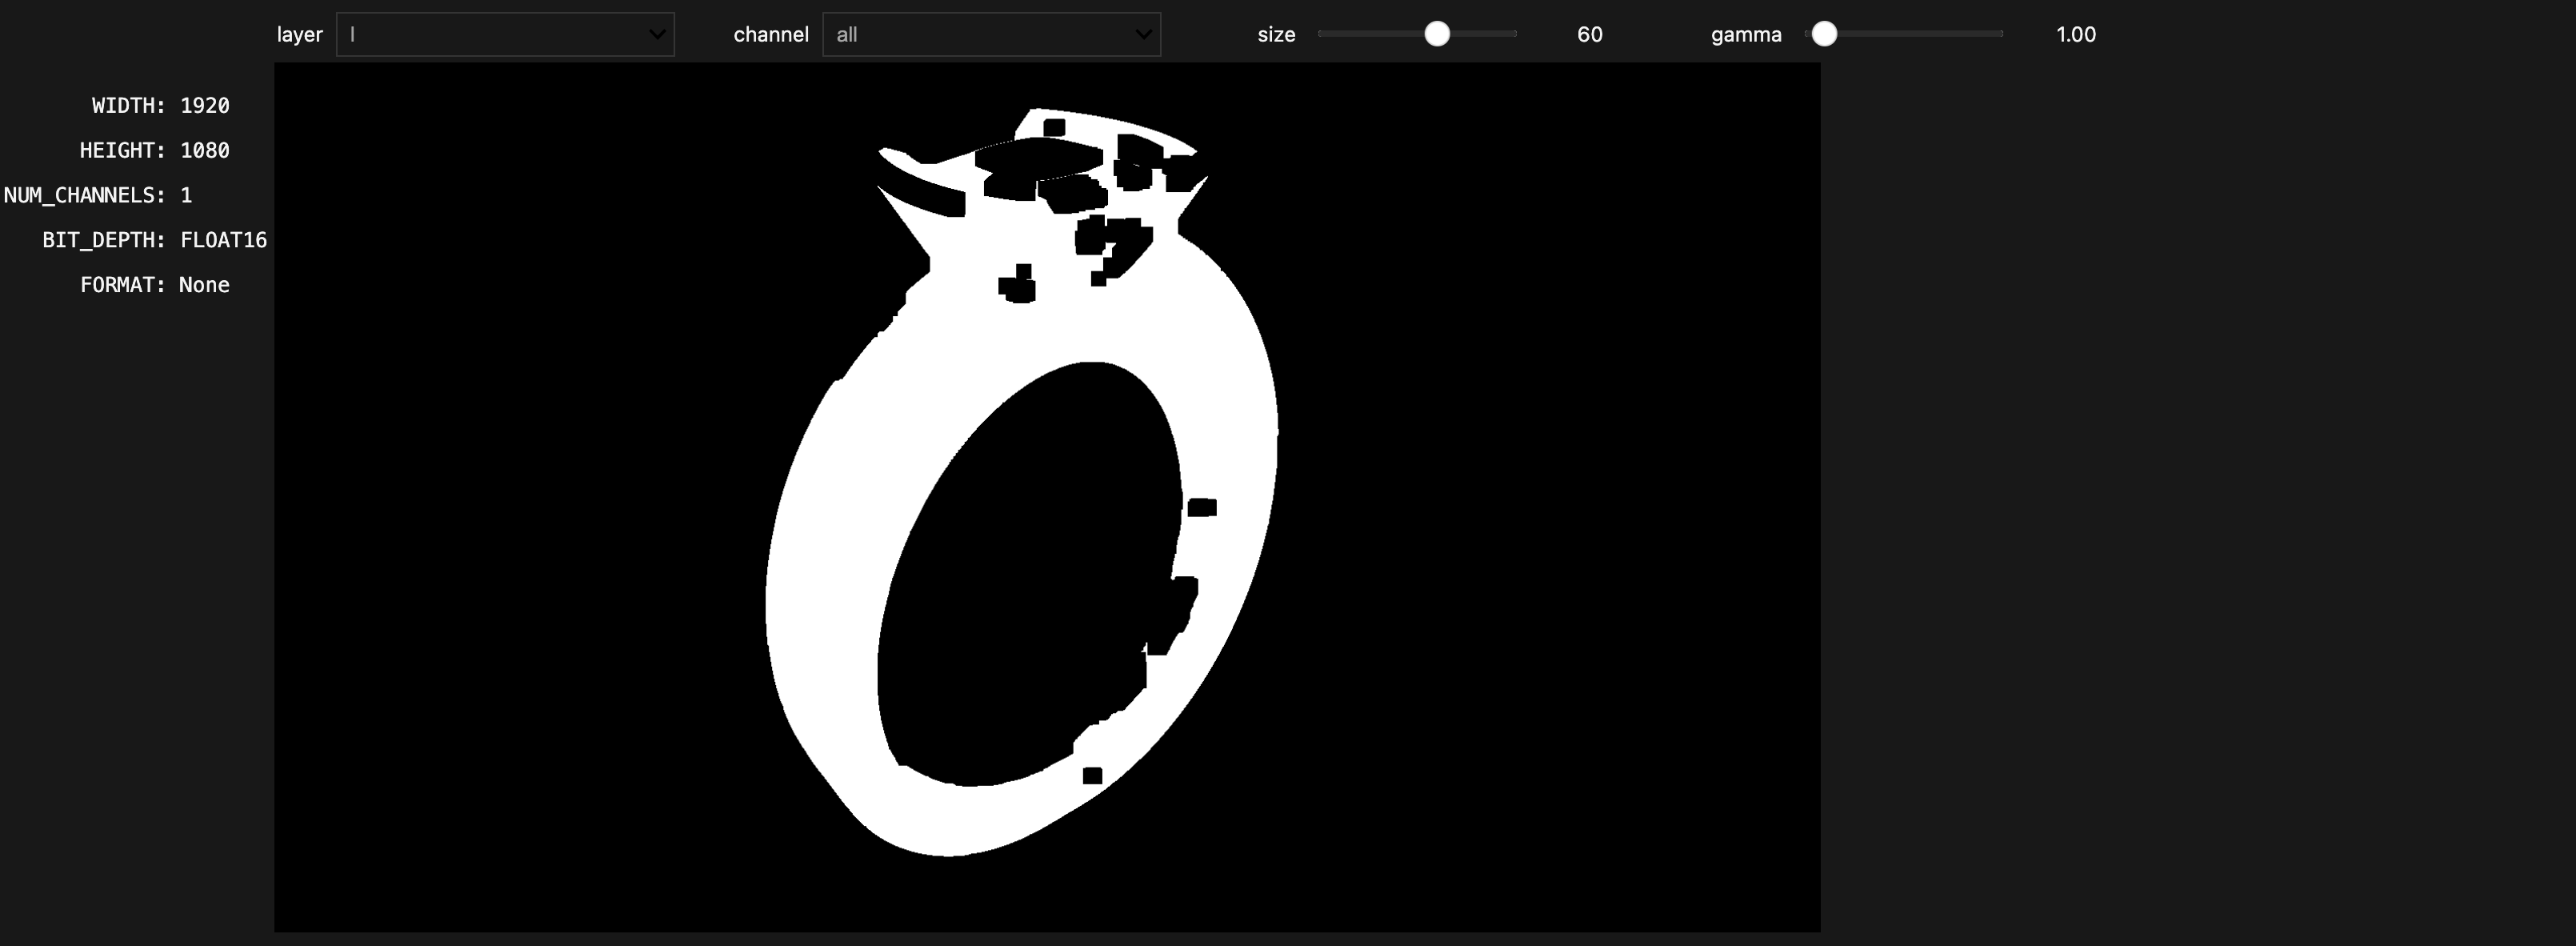

In [138]:
cvd.ops.filter.tophat(key, amount=9, kind='open')